In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [3]:
df = pd.read_csv("../data/raw_dataset.csv")

df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(920, 16)
<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB
None
               id         age    trestbps        chol      thalch     oldpeak  \
count  920.000000  920.000000  861.0

In [5]:
df.to_csv("../data/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [8]:
df.drop(columns=["id"], inplace=True)

In [9]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [10]:
categorical_columns = df.select_dtypes(include=["object"]).columns

for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

C:\Users\shans\AppData\Local\Temp\ipykernel_24740\1114755187.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


In [11]:
print(df.isnull().sum())

age         0
sex         0
dataset     0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64


In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df["num"] = (df["num"] > 0).astype(int)

In [14]:
df.to_csv("../data/cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


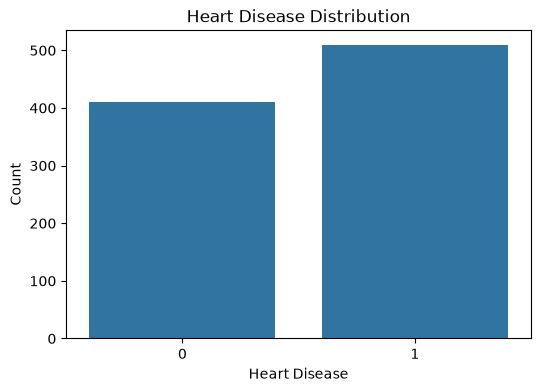

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x="num", data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.savefig("../images/heart_disease_distribution.png")

plt.show()

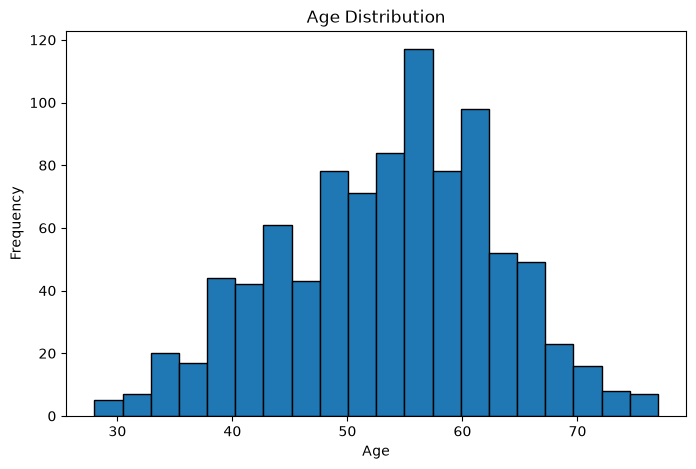

In [16]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("../images/age_distribution.png")

plt.show()

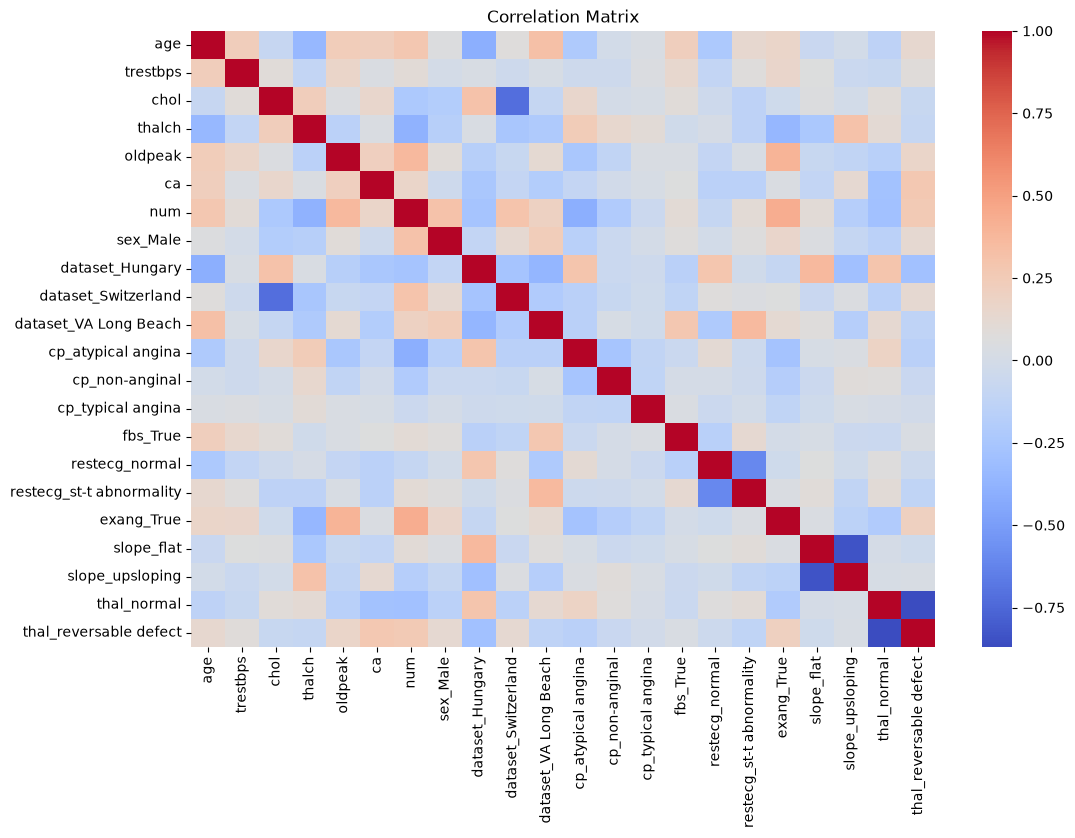

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),
            annot=False,
            cmap="coolwarm")

plt.title("Correlation Matrix")

plt.savefig("../images/correlation_matrix.png")

plt.show()

In [18]:
X = df.drop("num", axis=1)

y = df["num"]

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [22]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, log_pred))

print(classification_report(y_test, log_pred))

Accuracy: 0.8315217391304348
              precision    recall  f1-score   support

           0       0.78      0.81      0.80        75
           1       0.87      0.84      0.86       109

    accuracy                           0.83       184
   macro avg       0.82      0.83      0.83       184
weighted avg       0.83      0.83      0.83       184



In [23]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, classification_report

print("Decision Tree Accuracy:", accuracy_score(y_test, tree_pred))

print(classification_report(y_test, tree_pred))

Decision Tree Accuracy: 0.7717391304347826
              precision    recall  f1-score   support

           0       0.69      0.79      0.74        75
           1       0.84      0.76      0.80       109

    accuracy                           0.77       184
   macro avg       0.77      0.77      0.77       184
weighted avg       0.78      0.77      0.77       184



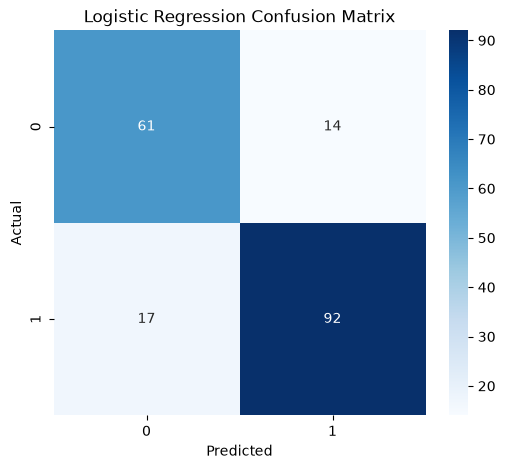

In [25]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, log_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../images/logistic_confusion_matrix.png")

plt.show()

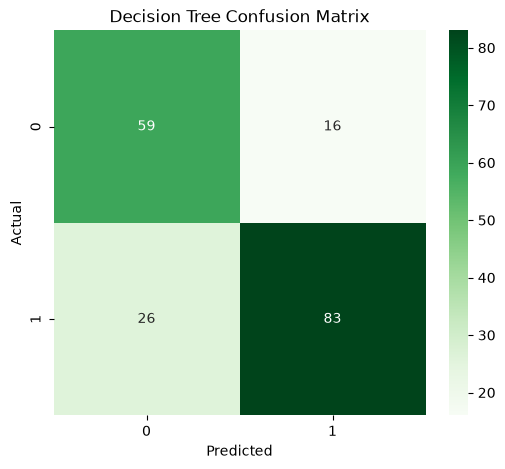

In [27]:
cm = confusion_matrix(y_test, tree_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../images/decision_tree_confusion_matrix.png")

plt.show()

In [28]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, log_pred),
        accuracy_score(y_test, tree_pred)
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.831522
1,Decision Tree,0.771739


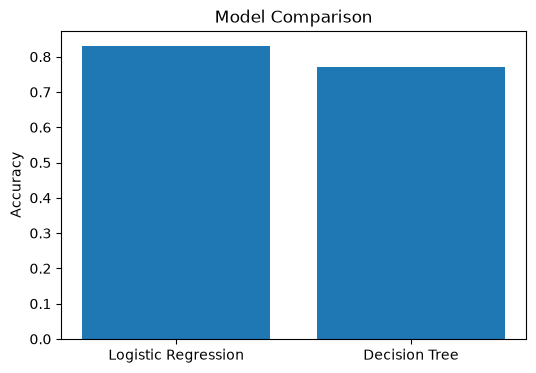

In [29]:
plt.figure(figsize=(6,4))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Comparison")
plt.ylabel("Accuracy")

plt.savefig("../images/model_comparison.png")

plt.show()

In [30]:
df.to_csv("../data/final_cleaned_dataset.csv", index=False)

print("Final dataset saved successfully!")

Final dataset saved successfully!
